In [211]:
using Pkg
Pkg.activate(".")
using LaTeXStrings, LinearAlgebra, PsfUnmixing, Statistics, Random
using PyPlot


  Activating project at `~/PsfUnmixing`


In [212]:
function lipschitz_constant(k, θ_min, θ_max, dictionary, xgrid; omega_samples=100)
    θ_range = range(θ_min, θ_max, length=omega_samples)
    opnorms = zeros(Float64, length(θ_range), length(dictionary))
    for (i, θ) in enumerate(θ_range)
        for (j ,group) in enumerate(dictionary)
           opnorms[i,j] = opnorm(single_block(k, θ, group, xgrid)) 
        end
    end
    return maximum(opnorms)
end

lipschitz_constant (generic function with 1 method)

In [213]:
function maximum_spectral_radius(
	k,
	θ_min,
	θ_max,
	Δ,
	T,
	p,
	d,
	xgrid;
	mc_trials = 10,
	omega_samples = 10,
)
	ρ = zeros(mc_trials)
	for i in 1:mc_trials
		dictionary = generate_spike_groups(rng, -T, T, Δ, p, d)
		ρ[i] = lipschitz_constant(
			k,
			θ_min,
			θ_max,
			dictionary,
			xgrid,
			omega_samples = omega_samples,
		)
	end
	return mean(ρ), std(ρ)
end


maximum_spectral_radius (generic function with 1 method)

In [214]:
function spectral_radius_experiment(
	k,
	θ_min,
	θ_max,
	T,
	p,
	d;
	Δ_min = 1e-3,
	Δ_max = 1e-1,
	mc_trials = 10,
	x_samples = 1000,
	omega_samples = 10,
	sep_samples = 10,
)
	xgrid = range(-T, T, x_samples)
	Δ = range(Δ_min, Δ_max, sep_samples)
	means = zeros(sep_samples)
	stds  = zeros(sep_samples)
	for (i, δ) in enumerate(Δ)
		means[i], stds[i] = maximum_spectral_radius(
			k,
			θ_min,
			θ_max,
			δ,
			T,
			p,
			d,
			xgrid;
			mc_trials = mc_trials,
			omega_samples = omega_samples,
		)
	end
	return means, stds
end


spectral_radius_experiment (generic function with 1 method)

In [215]:
function mu_local(grid, k, θ, Δ)
	return abs(dot(k(θ, grid), k(θ, grid .- Δ)))
end

function coherence_local(grid, k, θ, Δ; M = 100)
	return sum(mu_local(grid, k, θ, m * Δ) for m ∈ -M:M)
end

coherence_local (generic function with 1 method)

In [216]:
function lipschitz_coherence(
	k,
	θ_min,
	θ_max,
	Δ,
	xgrid;
	omega_samples = 100,
	coherence_sum_samples = 10,
)
	θ_range = range(θ_min, θ_max, length = omega_samples)
	opnorms = zeros(Float64, length(θ_range))
	for (i, θ) in enumerate(θ_range)
		opnorms[i] = coherence_local(
			xgrid,
			k,
			θ,
			Δ,
			M = coherence_sum_samples,
		)
	end
	return maximum(opnorms)
end

function coherence_experiment(
	k,
	θ_min,
	θ_max,
	T;
	Δ_min = 1e-3,
	Δ_max = 1e-1,
	x_samples = 10_000,
	omega_samples = 10,
	sep_samples = 10,
	coherence_sum_samples = 10,
)
	xgrid = range(-T, T, x_samples)
	Δ = range(Δ_min, Δ_max, sep_samples)
	result = zeros(sep_samples)
	for (i, δ) in enumerate(Δ)
		result[i] = lipschitz_coherence(
			k,
			θ_min,
			θ_max,
			δ,
			xgrid;
			omega_samples = omega_samples,
			coherence_sum_samples = coherence_sum_samples,
		)
	end
	return result
end


coherence_experiment (generic function with 1 method)

In [217]:
u = 2 # naturalized gaussian kernel

T = 1.0
p = 2
d = 2

s_min = 1e-3
s_max = 1e-2

θ_min = s_laplace(s_min, u, s_min)
θ_max = s_laplace(s_max, u, s_min) 

k_0(θ, t) = laplace_0_n(θ, t, u, umin=s_min)
k_1(θ, t) = laplace_1_n(θ, t, u, umin=s_min)
k_2(θ, t) = laplace_2_n(θ, t, u, umin=s_min)
k_3(θ, t) = laplace_3_n(θ, t, u, umin=s_min)

rng = MersenneTwister(0);

T = 1.0

sep_samples = 100;

In [218]:
Δ_min_1 = 7e-3
Δ_max_1 = 4e-2


x_samples = 10_000

mc_trials = 200

means_0, std_0 = spectral_radius_experiment(k_0, θ_min, θ_max, T, p, d, Δ_min=Δ_min_1, Δ_max=Δ_max_1, x_samples=x_samples, sep_samples=sep_samples, mc_trials=mc_trials)
means_1, std_1 = spectral_radius_experiment(k_1, θ_min, θ_max, T, p, d, Δ_min=Δ_min_1, Δ_max=Δ_max_1, x_samples=x_samples, sep_samples=sep_samples, mc_trials=mc_trials)


μ_0 = coherence_experiment(k_0, θ_min, θ_max, T, Δ_min=Δ_min_1, Δ_max=Δ_max_1, x_samples = x_samples, sep_samples=sep_samples, coherence_sum_samples=d)
μ_1 = coherence_experiment(k_1, θ_min, θ_max, T, Δ_min=Δ_min_1, Δ_max=Δ_max_1, x_samples = x_samples, sep_samples=sep_samples, coherence_sum_samples=d);

In [219]:
Δ_min_2 = 1e-3
Δ_max_2 = 5e-3

means_2, std_2 = spectral_radius_experiment(k_2, θ_min, θ_max, T, p, d, Δ_min=Δ_min_2, Δ_max=Δ_max_2, x_samples=x_samples, sep_samples=sep_samples, mc_trials=mc_trials)
means_3, std_3 = spectral_radius_experiment(k_3, θ_min, θ_max, T, p, d, Δ_min=Δ_min_2, Δ_max=Δ_max_2, x_samples=x_samples, sep_samples=sep_samples, mc_trials=mc_trials)

μ_2 = coherence_experiment(k_2, θ_min, θ_max, T, Δ_min=Δ_min_2, Δ_max=Δ_max_2, x_samples = x_samples, sep_samples=sep_samples, coherence_sum_samples=d+1)
μ_3 = coherence_experiment(k_3, θ_min, θ_max, T, Δ_min=Δ_min_2, Δ_max=Δ_max_2, x_samples = x_samples, sep_samples=sep_samples, coherence_sum_samples=d+1);

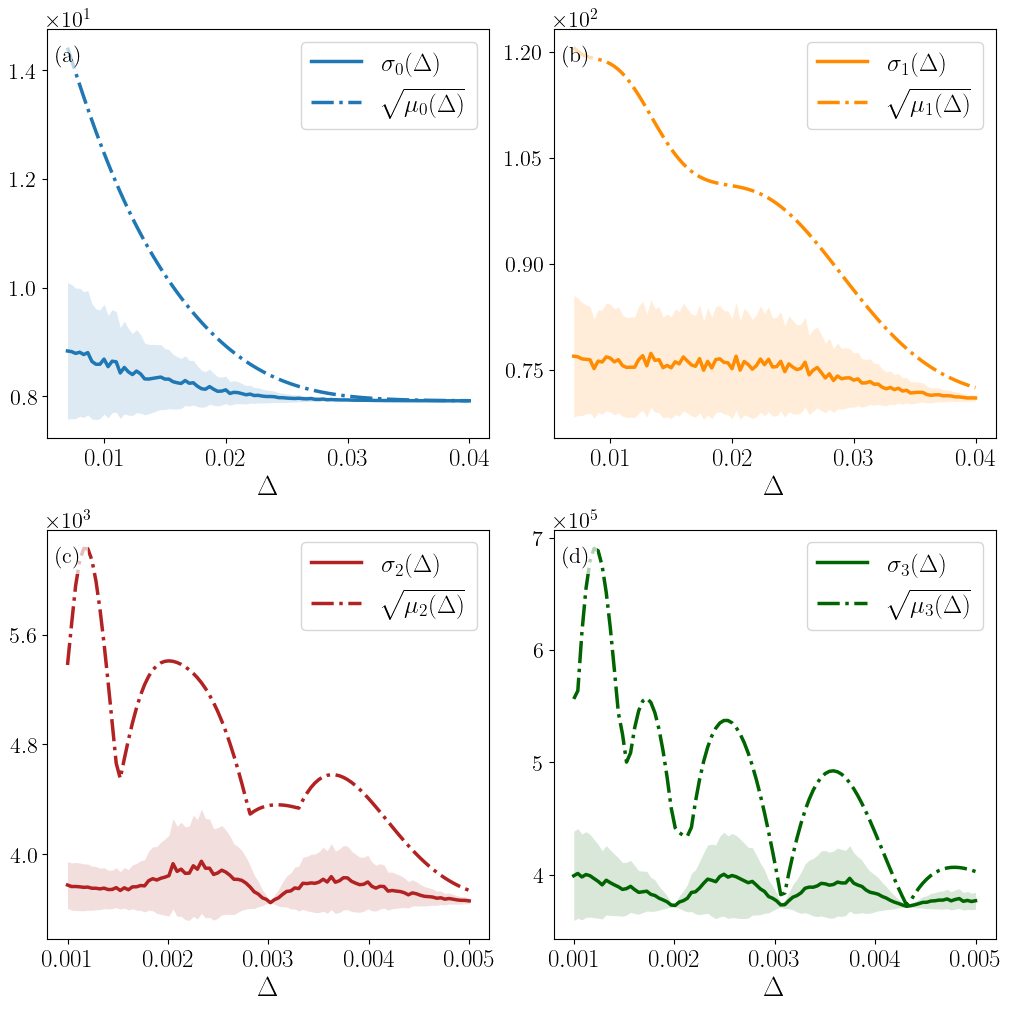

In [220]:
using PyPlot
using LaTeXStrings

PyPlot.rc("text", usetex=true)
PyPlot.rc("font", family="serif")

const mpl = PyPlot.matplotlib

to_vec(x) = collect(Float64.(x))

function plot_with_ribbon(ax, Δ, means, std, μ; color, labσ, labμ)

    Δv     = to_vec(Δ)
    meansv = to_vec(means)
    stdv   = to_vec(std)
    μv     = (μ isa Number) ? fill(Float64(μ), length(Δv)) : to_vec(μ)

    ax.plot(Δv, meansv; color=color, linestyle="-",  linewidth=2.5, label=labσ)
    ax.fill_between(Δv, meansv .- stdv, meansv .+ stdv;
                    color=color, alpha=0.15, linewidth=0)
    ax.plot(Δv, sqrt.(μv); color=color, linestyle="-.", linewidth=2.5, label=labμ)

    ax.set_xlabel(L"\Delta", fontsize=20)

    ax.tick_params(axis="x", labelsize=18)
    ax.tick_params(axis="y", labelsize=16)

    ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(4))

    # Proper scientific notation
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
    ax.yaxis.get_offset_text().set_fontsize(16)

    ax.legend(loc="upper right", fontsize=18, frameon=true)
end

# IMPORTANT: keep as vectors
Δ_1 = collect(range(Δ_min_1, Δ_max_1; length=sep_samples))
Δ_2 = collect(range(Δ_min_2, Δ_max_2; length=sep_samples))

fig, axs = subplots(2, 2, figsize=(10, 10), constrained_layout=true)

ax00 = axs[1,1]
ax01 = axs[1,2]
ax10 = axs[2,1]
ax11 = axs[2,2]

# --- Top left ---
plot_with_ribbon(ax00, Δ_1, means_0, std_0, μ_0;
    color="tab:blue",
    labσ=L"\sigma_0(\Delta)",
    labμ=L"\sqrt{\mu_0(\Delta)}"
)

# --- Top right ---
plot_with_ribbon(ax01, Δ_1, means_1, std_1, μ_1;
    color="darkorange",
    labσ=L"\sigma_1(\Delta)",
    labμ=L"\sqrt{\mu_1(\Delta)}"
)

# --- Bottom left ---
plot_with_ribbon(ax10, Δ_2, means_2, std_2, μ_2;
    color="firebrick",
    labσ=L"\sigma_2(\Delta)",
    labμ=L"\sqrt{\mu_2(\Delta)}"
)

# --- Bottom right ---
plot_with_ribbon(ax11, Δ_2, means_3, std_3, μ_3;
    color="darkgreen",
    labσ=L"\sigma_3(\Delta)",
    labμ=L"\sqrt{\mu_3(\Delta)}"
)

for (lab, ax) in zip(["(a)", "(b)", "(c)", "(d)"], [ax00, ax01, ax10, ax11])
    ax.text(0.02, 0.96, lab; transform=ax.transAxes,
        va="top", ha="left", fontsize=16,
        bbox=Dict("facecolor"=>"white","alpha"=>0.7,"edgecolor"=>"none"))
end

fig.savefig("figures/tsp_coherence.pdf", bbox_inches="tight")
fig


In [225]:
u_ = 6 # naturalized gaussian kernel

T = 1.0
p = 2
d = 2

s_min = 1e-3
s_max = 1e-2

θ_min = s_laplace(s_min, u_, s_min)
θ_max = s_laplace(s_max, u_, s_min) 

k_0_5(θ, t) = laplace_0_n(θ, t, u_, umin=s_min)
k_1_5(θ, t) = laplace_1_n(θ, t, u_, umin=s_min)

rng = MersenneTwister(0);

T = 1.0

sep_samples = 100;

In [226]:
Δ_min_1 = 7e-3
Δ_max_1 = 4e-2


means_0_5, std_0_5 = spectral_radius_experiment(k_0_5, θ_min, θ_max, T, p, d, Δ_min=Δ_min_1, Δ_max=Δ_max_1, x_samples=x_samples, sep_samples=sep_samples, mc_trials=mc_trials)
means_1_5, std_1_5 = spectral_radius_experiment(k_1_5, θ_min, θ_max, T, p, d, Δ_min=Δ_min_1, Δ_max=Δ_max_1, x_samples=x_samples, sep_samples=sep_samples, mc_trials=mc_trials)

μ_0_5 = coherence_experiment(k_0_5, θ_min, θ_max, T, Δ_min=Δ_min_1, Δ_max=Δ_max_1, x_samples = x_samples, sep_samples=sep_samples, coherence_sum_samples=d)
μ_1_5 = coherence_experiment(k_1_5, θ_min, θ_max, T, Δ_min=Δ_min_1, Δ_max=Δ_max_1, x_samples = x_samples, sep_samples=sep_samples, coherence_sum_samples=d);

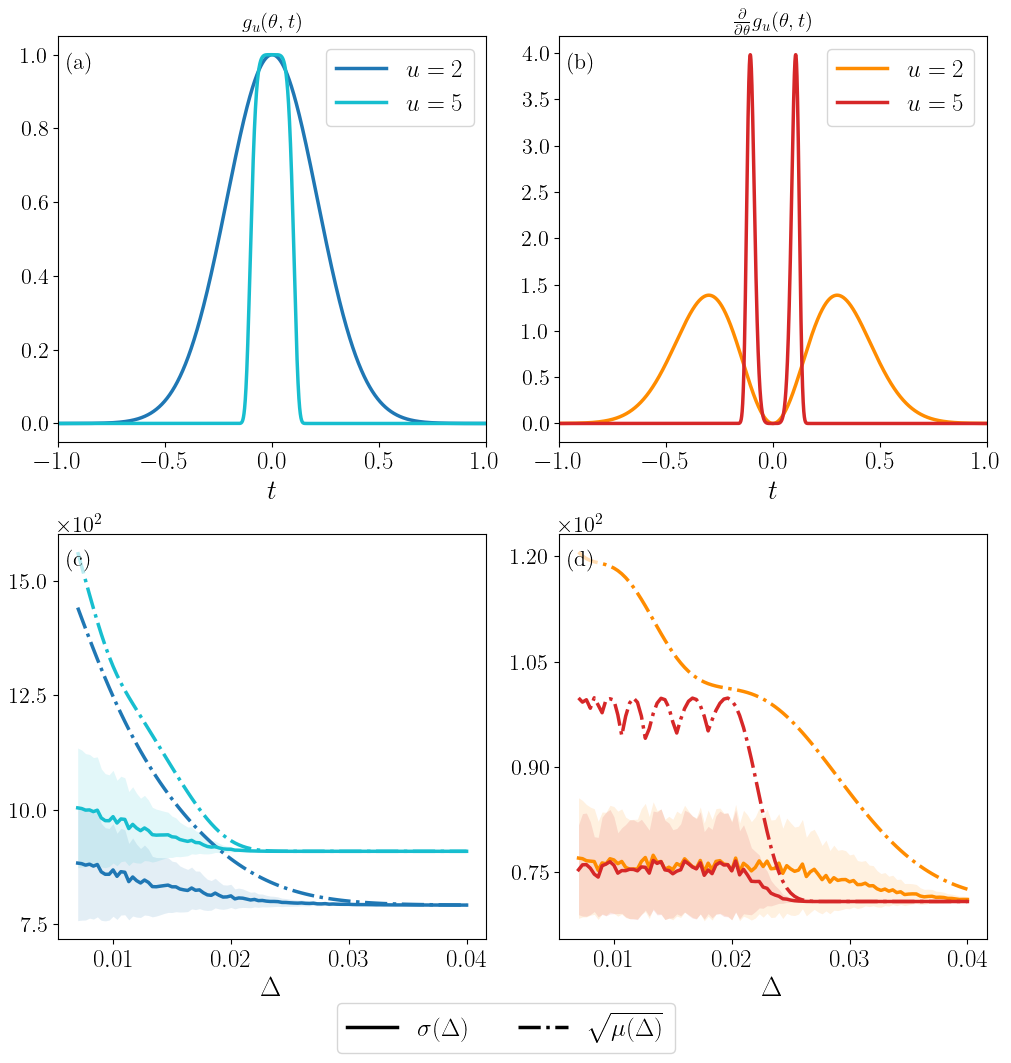

In [228]:
using PyPlot
const mpl = PyPlot.matplotlib

# better xgrid construction (if x_samples is intended to be the number of points)
xgrid = collect(range(-T, T; length=x_samples))

fig, axs = subplots(2, 2; figsize=(10, 10), constrained_layout=true)
ax00 = axs[1,1]   # top-left
ax01 = axs[1,2]   # top-right
ax10 = axs[2,1]   # bottom-left
ax11 = axs[2,2]   # bottom-right

θ_star = s_laplace(3e-1, u, s_min)

# ---------- top-left: k0 ----------
h1 = ax00.plot(xgrid, k_0(θ_star, xgrid);
    color="tab:blue", linewidth=2.5, label=L"u=2")[1]
h2 = ax00.plot(xgrid, k_0_5(θ_star, xgrid);
    color="tab:cyan",  linewidth=2.5, label=L"u=5")[1]
ax00.set_title(L"$g_u(\theta, t)$", fontsize=15)
ax00.set_xlabel(L"t", fontsize=20)
ax00.legend(loc="upper right", fontsize=18, frameon=true)
# ax00.set_ylabel(L"amplitude")

ax00.tick_params(axis="x", labelsize=18)
ax00.tick_params(axis="y", labelsize=16)

# ---------- top-right: k1 ----------
h3 = ax01.plot(xgrid, k_1(θ_star, xgrid);
    color="darkorange", linewidth=2.5, label=L"u=2")[1]
h4 = ax01.plot(xgrid, k_1_5(θ_star, xgrid);
    color="tab:red",     linewidth=2.5, label=L"u=5")[1]
ax01.set_title(L"$\frac{\partial}{\partial \theta} g_u(\theta, t)$", fontsize=15)
ax01.set_xlabel(L"t", fontsize=20)
ax01.legend(loc="upper right", fontsize=18, frameon=true)

ax01.tick_params(axis="x", labelsize=18)
ax01.tick_params(axis="y", labelsize=16)

# ---------- bottom panels helper ----------
function plot_with_ribbon!(ax, Δ, means, std, μ; color, scale=1.0)
    Δv     = to_vec(Δ)
    meansv = scale .* to_vec(means)
    stdv   = scale .* to_vec(std)
    μv     = (μ isa Number) ? fill(Float64(μ), length(Δv)) : to_vec(μ)
    μplot  = scale .* sqrt.(μv)

    lσ = ax.plot(Δv, meansv; color=color, linestyle="-",  linewidth=2.5)[1]
    ax.fill_between(Δv, meansv .- stdv, meansv .+ stdv;
        color=color, alpha=0.12, linewidth=0)   # lighter ribbon
    lμ = ax.plot(Δv, μplot;   color=color, linestyle="-.", linewidth=2.5)[1]


    ax.tick_params(axis="x", labelsize=18)
    ax.tick_params(axis="y", labelsize=16)

    ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
    ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(4))

    ax.ticklabel_format(axis="y", style="sci", scilimits=(2,2))
    ax.yaxis.get_offset_text().set_fontsize(16)
    return lσ, lμ
end

# ---------- bottom-left: σ0 and √μ0 (scaled ×1e2) ----------
lσ2, lμ2 = plot_with_ribbon!(ax10, Δ_1, means_0,   std_0,   μ_0;   color="tab:blue", scale=1e2)
lσ5, lμ5 = plot_with_ribbon!(ax10, Δ_1, means_0_5, std_0_5, μ_0_5; color="tab:cyan",  scale=1e2)
ax10.set_xlabel(L"\Delta", fontsize=20)
# ax10.set_ylabel(L"value ($\times 10^2$)")


# ---------- bottom-right: σ1 and √μ1 ----------
rσ2, rμ2 = plot_with_ribbon!(ax11, Δ_1, means_1,   std_1,   μ_1;   color="darkorange")
rσ5, rμ5 = plot_with_ribbon!(ax11, Δ_1, means_1_5, std_1_5, μ_1_5; color="tab:red")
ax11.set_xlabel(L"\Delta", fontsize=20)

# ---------- panel labels (a)-(d) ----------
for (lab, ax) in zip(["(a)", "(b)", "(c)", "(d)"], [ax00, ax01, ax10, ax11])
    ax.text(0.02, 0.96, lab; transform=ax.transAxes,
        va="top", ha="left", fontsize=16,
        bbox=Dict("facecolor"=>"white","alpha"=>0.7,"edgecolor"=>"none"))
end

# ---------- legends: one for top row, one for bottom row ----------
# top legend: colors = u, placed above top row
# fig.legend([h1, h2, h3, h4], [L"u=2", L"u=5", L"u=2", L"u=5"];
#     loc="upper center", ncol=4, frameon=true, bbox_to_anchor=(0.5, 1.06), fontsize=18)

# bottom legend: colors = u AND linestyle = statistic (compact)
# create dummy handles for linestyle meaning
dσ = mpl.lines.Line2D([], []; color="black", linestyle="-",  linewidth=2.5)
dμ = mpl.lines.Line2D([], []; color="black", linestyle="-.", linewidth=2.5)
du2 = mpl.lines.Line2D([], []; color="tab:blue", linestyle="-", linewidth=2.5)
du5 = mpl.lines.Line2D([], []; color="tab:red",  linestyle="-", linewidth=2.5)

fig.legend([dσ, dμ],
           [L"\sigma(\Delta)", L"\sqrt{\mu(\Delta)}"];
    loc="lower center", ncol=2, frameon=true, bbox_to_anchor=(0.5, -0.06), fontsize=18)

# optional: tighten x-lims for top row (symmetry)
ax00.set_xlim(-T, T)
ax01.set_xlim(-T, T)

fig.savefig("figures/tsp_coherence_decay.pdf", bbox_inches="tight")
fig
